In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv('../data/bank/bank-full.csv', sep=';')
df.shape

(45211, 17)

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [5]:
df.dtypes.value_counts()


str      10
int64     7
Name: count, dtype: int64

In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [7]:
df['y'].value_counts(normalize=True)*100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

We wanted to check the proportions of the two outputs to understand which metric to use, like we found the proportion here to be 88 percent and 11 percent roughly so if I use a bad model which predicts no everytime it will hsve a prediction of 88 percent which is a bad metric.

Observations so far
y is heavily imbalanced.
There are no actual missing values.
There are numerical and categorical variables.
duration may be unavailable in a genuine pre-call prediction setting.

In [8]:
job_props = pd.crosstab(df['job'], df['y'], normalize='index')
subscription_rate = job_props['yes']*100
subscription_rate = subscription_rate.sort_values(ascending=False)

C:\Users\M T Sulthana\AppData\Local\Temp\ipykernel_17464\873090410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subscription_rate.values, y=subscription_rate.index, palette='viridis')


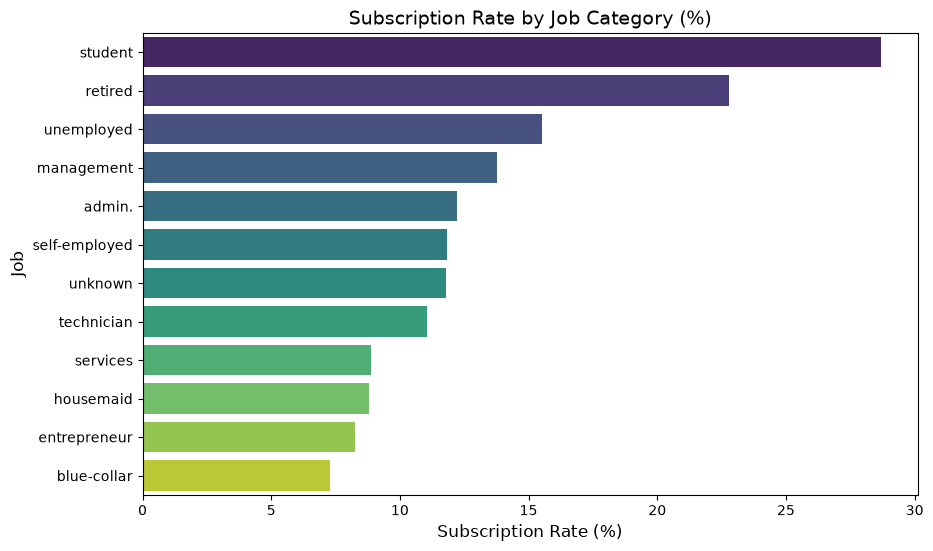

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x=subscription_rate.values, y=subscription_rate.index, palette='viridis')

plt.title('Subscription Rate by Job Category (%)', fontsize=14)
plt.xlabel('Subscription Rate (%)', fontsize=12)
plt.ylabel('Job', fontsize=12)

plt.show()

In [10]:
df[df['y']=='yes']['job'].value_counts()

job
management       1301
technician        840
blue-collar       708
admin.            631
retired           516
services          369
student           269
unemployed        202
self-employed     187
entrepreneur      123
housemaid         109
unknown            34
Name: count, dtype: int64

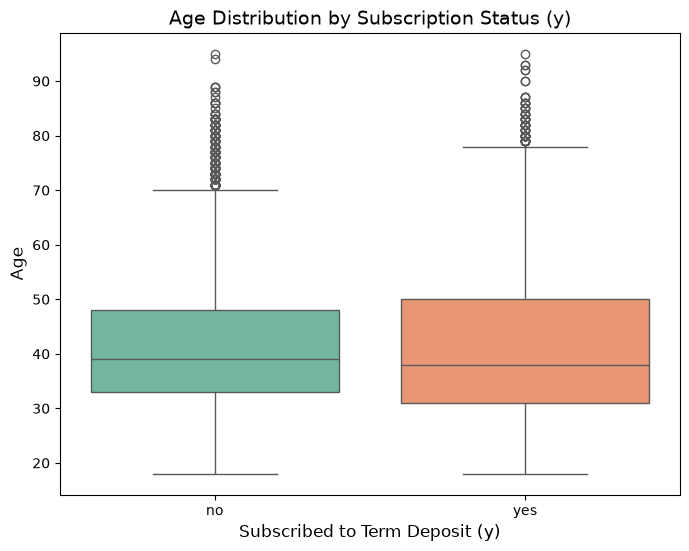

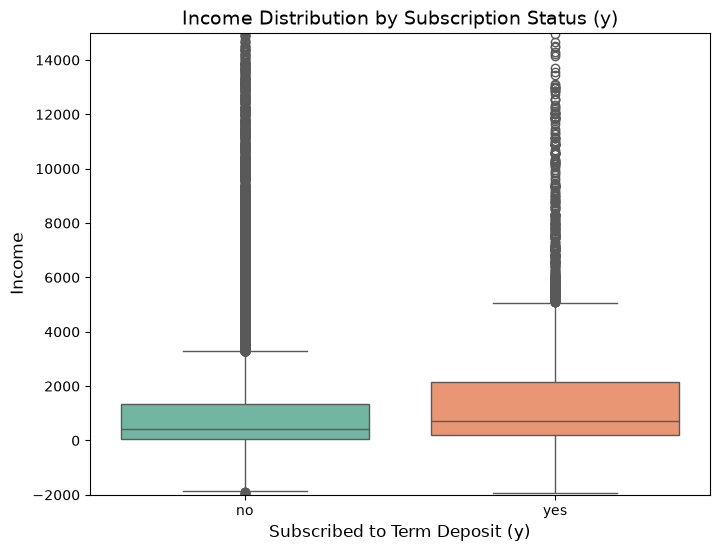

In [11]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='y', y='age', hue='y', palette='Set2', legend=False)

plt.title('Age Distribution by Subscription Status (y)', fontsize=14)
plt.xlabel('Subscribed to Term Deposit (y)', fontsize=12)
plt.ylabel('Age', fontsize=12)

plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='y', y='balance', hue='y', palette='Set2', legend=False)
plt.ylim(-2000, 15000)
plt.title('Income Distribution by Subscription Status (y)', fontsize=14)
plt.xlabel('Subscribed to Term Deposit (y)', fontsize=12)
plt.ylabel('Income', fontsize=12)
plt.show()

Subscribers have a higher median balance than non subscribers, but the distributios overlap substantially suggests that balance alone is unlikely to cleanly distinguish the two classes.

In [12]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

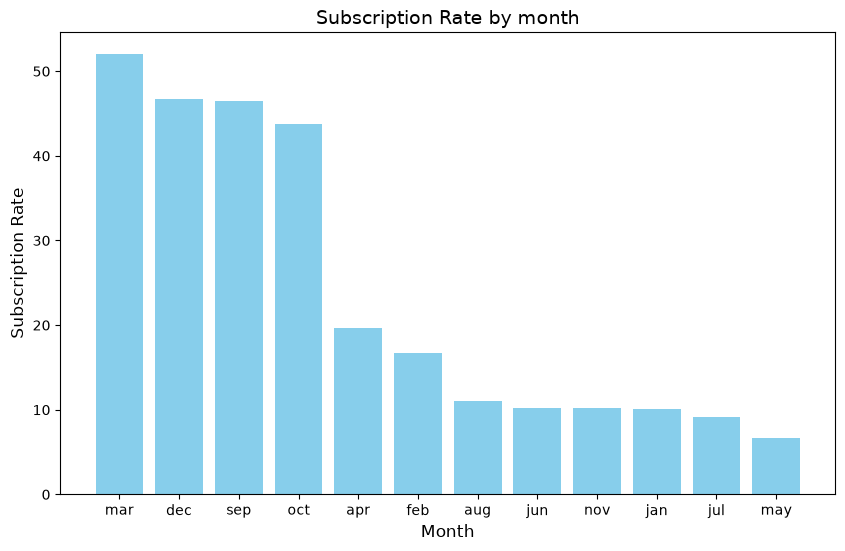

In [13]:
month_props = pd.crosstab(df['month'], df['y'], normalize='index')
month_sub_rate = month_props['yes']*100

month_sub_rate = month_sub_rate.sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(month_sub_rate.index, month_sub_rate.values, color='skyblue')

plt.title('Subscription Rate by month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Subscription Rate', fontsize=12)
plt.show()



In [14]:
pd.crosstab(df['month'],df['y'])

y,no,yes
month,,
apr,2355,577
aug,5559,688
dec,114,100
feb,2208,441
jan,1261,142
jul,6268,627
jun,4795,546
mar,229,248
may,12841,925


are these really differences caused by the month itself, or could something else about the marketing campaign be different in those months?

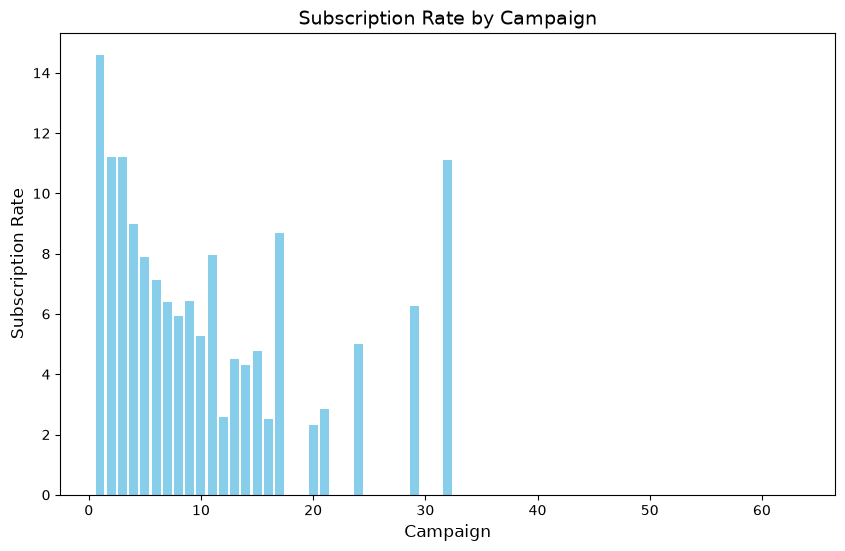

In [15]:
campaign_props = pd.crosstab(df['campaign'],df['y'],normalize='index')
campaign_sub_rate = campaign_props['yes']*100

campaign_sub_rate = campaign_sub_rate.sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(campaign_sub_rate.index, campaign_sub_rate.values, color='skyblue')

plt.title('Subscription Rate by Campaign', fontsize=14)
plt.xlabel('Campaign', fontsize=12)
plt.ylabel('Subscription Rate', fontsize=12)

plt.show()

Higher campaign contact counts are generally associated with lower subscription rates, although the rates become noisy at higher contact counts because the number of observations becomes small.

In [16]:
df['poutcome']

0        unknown
1        unknown
2        unknown
3        unknown
4        unknown
          ...   
45206    unknown
45207    unknown
45208    success
45209    unknown
45210      other
Name: poutcome, Length: 45211, dtype: str

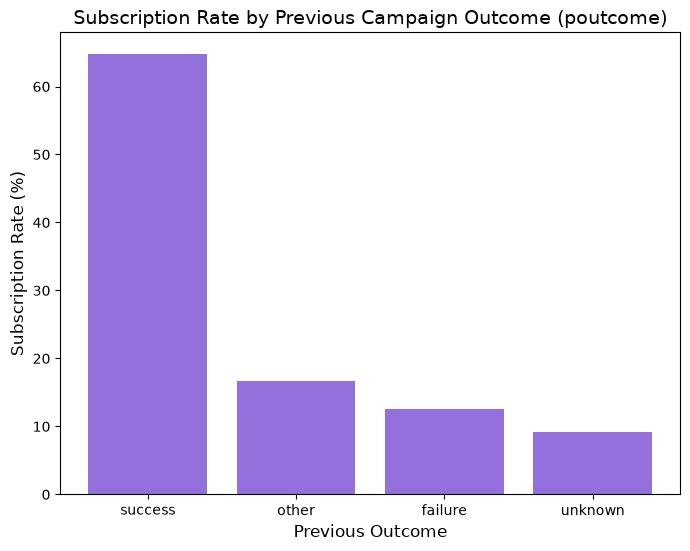

In [17]:

poutcome_props = pd.crosstab(df['poutcome'], df['y'], normalize='index')

poutcome_sub_rate = poutcome_props['yes'] * 100


poutcome_sub_rate = poutcome_sub_rate.sort_values(ascending=False)


plt.figure(figsize=(8, 6))
plt.bar(poutcome_sub_rate.index, poutcome_sub_rate.values, color='mediumpurple')


plt.title('Subscription Rate by Previous Campaign Outcome (poutcome)', fontsize=14)
plt.xlabel('Previous Outcome', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)

plt.show()

In [18]:
pd.crosstab(df['poutcome'], df['y'])

y,no,yes
poutcome,,
failure,4283,618
other,1533,307
success,533,978
unknown,33573,3386


Among customers whose previous campaign outcome was success, about 65% subscribed in this campaign. This strong difference in subscription rate suggests that poutcome may be an informative predictor.

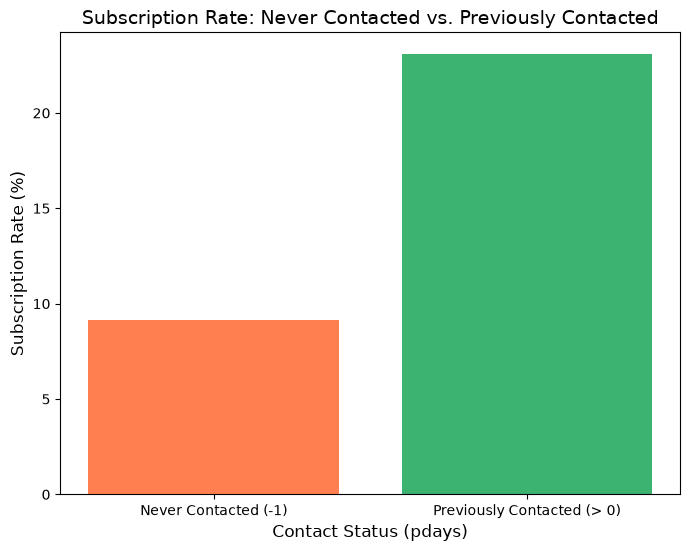

y,no,yes
contact_group,,
Never Contacted (-1),33570,3384
Previously Contacted (> 0),6352,1905


In [19]:

df['contact_group'] = np.where(df['pdays'] == -1, 'Never Contacted (-1)', 'Previously Contacted (> 0)')


pdays_props = pd.crosstab(df['contact_group'], df['y'], normalize='index')
pdays_sub_rate = pdays_props['yes'] * 100


plt.figure(figsize=(8, 6))
plt.bar(pdays_sub_rate.index, pdays_sub_rate.values, color=['coral', 'mediumseagreen'])
plt.title('Subscription Rate: Never Contacted vs. Previously Contacted', fontsize=14)
plt.xlabel('Contact Status (pdays)', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.show()

display(pd.crosstab(df['contact_group'], df['y']))

Customers with a previous contact have a substantially higher observed subscription rate than customers with no previous contact.

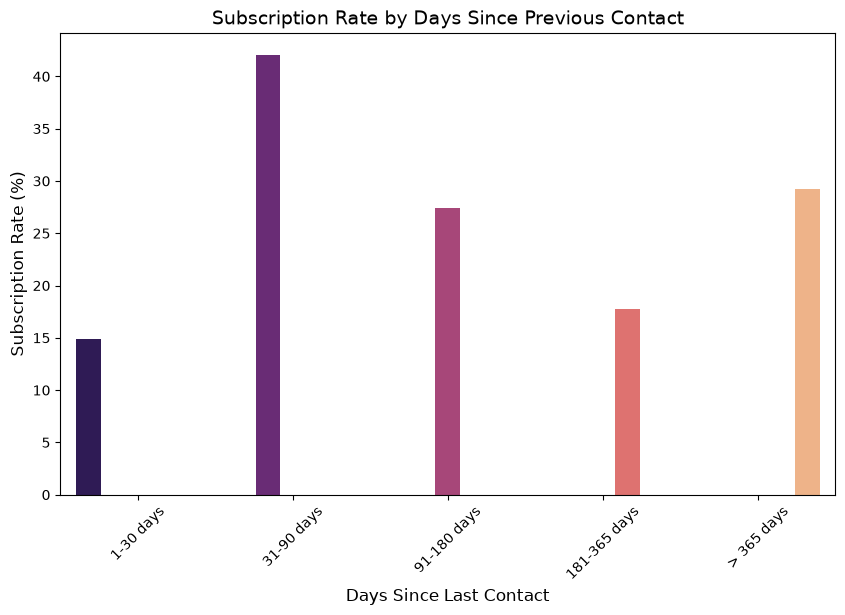

y,no,yes
pdays_binned,,
1-30 days,160,28
31-90 days,307,223
91-180 days,1800,680
181-365 days,3630,786
> 365 days,455,188


In [20]:

df_contacted = df[df['pdays'] > 0].copy()

bins = [0, 30, 90, 180, 365, df_contacted['pdays'].max()]
labels = ['1-30 days', '31-90 days', '91-180 days', '181-365 days', '> 365 days']

df_contacted['pdays_binned'] = pd.cut(df_contacted['pdays'], bins=bins, labels=labels)

binned_props = pd.crosstab(df_contacted['pdays_binned'], df_contacted['y'], normalize='index')
binned_sub_rate = binned_props['yes'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=binned_sub_rate.index, y=binned_sub_rate.values, hue=binned_sub_rate.index, palette='magma', legend=False)
plt.title('Subscription Rate by Days Since Previous Contact', fontsize=14)
plt.xlabel('Days Since Last Contact', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

display(pd.crosstab(df_contacted['pdays_binned'], df_contacted['y']))

pdays appears to have a non-linear relationship with subscription, with the highest observed subscription rate occurring when the previous contact was around 31–90 days ago. However, the relationship isn't simply linear as the time since contact increases.

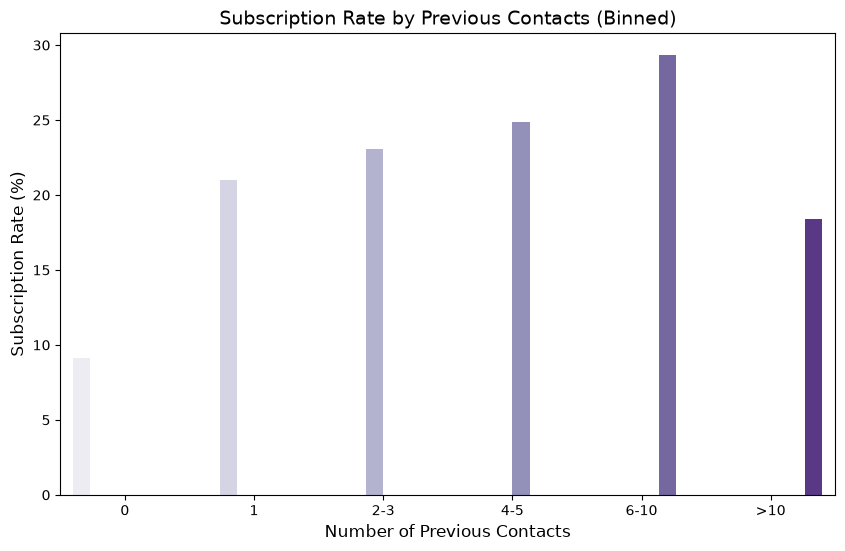

y,no,yes
previous_binned,,
0,33570,3384
1,2189,583
2-3,2498,750
4-5,881,292
6-10,544,226
>10,240,54


In [22]:

prev_bins = [-1, 0, 1, 3, 5, 10, df['previous'].max()]
prev_labels = ['0', '1', '2-3', '4-5', '6-10', '>10']


df['previous_binned'] = pd.cut(df['previous'], bins=prev_bins, labels=prev_labels)


prev_binned_props = pd.crosstab(df['previous_binned'], df['y'], normalize='index')
prev_binned_rate = prev_binned_props['yes'] * 100


plt.figure(figsize=(10, 6))
sns.barplot(x=prev_binned_rate.index, y=prev_binned_rate.values, hue=prev_binned_rate.index, palette='Purples', legend=False)
plt.title('Subscription Rate by Previous Contacts (Binned)', fontsize=14)
plt.xlabel('Number of Previous Contacts', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.show()


display(pd.crosstab(df['previous_binned'], df['y']))

Subscription rate generally increases as the number of previous contacts increases, reaching its highest level for customers with 6–10 previous contacts. For customers with more than 10 previous contacts, the rate falls, but this group has a much smaller sample size, so the decline should be interpreted cautiously.